# Import Required Libraries

Import necessary libraries such as NumPy, PIL, Torch, and the FPIInference model.

In [23]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Import the FPIInference model
from fpi_model import FPIInference

In [24]:
import models.taskflow as taskflow
import argparse
from mmcv import Config
import os

In [67]:
config_path = 'example_config.py'
checkpoint_path = 'checkpoints/CvT-13-384x384-IN-22k.pth'
def get_opt():
    parser = argparse.ArgumentParser(description='Training')
    parser.add_argument('--config', default=config_path,
                        type=str, help='training dir path')
    parser.add_argument('--checkpoint', default=checkpoint_path, type=str, help='')
    parser.add_argument('--save_nums', default=10, type=int, help='')
    parser.add_argument('--seed', default=666, type=int, help='')
    
    opt = parser.parse_args()
    save_dir = opt.checkpoint.split("/net_best.pth")[0]
    save_dir= os.path.join(save_dir,"visualize")
    opt.save_dir = save_dir

    cfg = Config.fromfile(opt.config)
    for key, value in cfg.items():
        if key not in opt:
            setattr(opt, key, value)
    return opt

In [68]:
import os
from types import SimpleNamespace
from mmcv import Config

def get_opt_direct(config_path, checkpoint_path, save_nums=10, seed=666):
    """
    Создает объект opt без использования argparse.
    """
    # Инициализация базового объекта opt
    opt = SimpleNamespace()
    opt.config = config_path
    opt.checkpoint = checkpoint_path
    opt.save_nums = save_nums
    opt.seed = seed

    # Формирование save_dir
    save_dir = opt.checkpoint.split("/net_best.pth")[0]
    save_dir = os.path.join(save_dir, "visualize")
    opt.save_dir = save_dir

    # Загрузка конфигурации
    cfg = Config.fromfile(opt.config)

    # Копирование параметров конфигурации в opt
    for key, value in cfg.items():
        if not hasattr(opt, key):
            setattr(opt, key, value)

    return opt

# Load the Model from fpi_model

Load the pre-trained FPI model using the FPIInference class. You need to provide paths to the config and checkpoint files.

In [69]:
# Paths to config and checkpoint (adjust as needed)
config_path = 'example_config.py'
checkpoint_path = 'checkpoints/CvT-13-384x384-IN-22k.pth'

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize the model
fpi_model = FPIInference(config_path, checkpoint_path, device=device)
print("Model loaded successfully!")

Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: ['head.weight', 'head.bias']
Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: ['head.weight', 'head.bias']
Model loaded successfully!


# Prepare Input Data

Load UAV and satellite images. For demonstration, we'll use placeholder images or load from files.

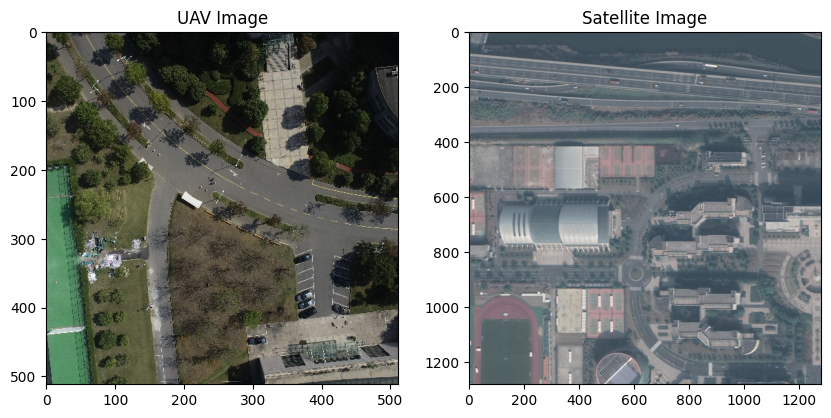

In [70]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'C:\Users\roman\OneDrive\Документы\GitHub\satellite-geolocation\map2019\train\Caijing_000000\UAV\0.JPG'  # Example path
satellite_image_path = r'C:\Users\roman\OneDrive\Документы\GitHub\satellite-geolocation\map2019\train\Caijing_000000\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

# Run Model Inference

Use the loaded model to predict the pixel coordinates on the satellite image corresponding to the UAV image.

In [71]:
# Run prediction
result = fpi_model.predict(uav_image, satellite_image, return_heatmap=True)

# Extract results
pixel_coord = result['pixel_coordinate']
pixel_norm = result['pixel_normalized']
heatmap = result['heatmap']

print(f"Predicted pixel coordinate: {pixel_coord}")
print(f"Normalized coordinate: {pixel_norm}")

Predicted pixel coordinate: (228, 352)
Normalized coordinate: (0.3958333333333333, 0.6111111111111112)


# Display and Analyze Results

Visualize the heatmap overlay on the satellite image and analyze the prediction.

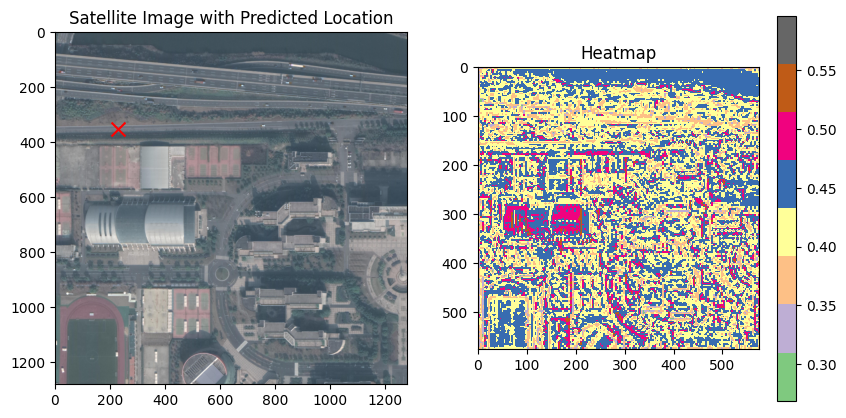

Analysis: The red X marks the predicted location of the UAV object on the satellite image.


In [72]:
# Visualize the heatmap
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(satellite_image)
plt.scatter(pixel_coord[0], pixel_coord[1], color='red', s=100, marker='x')
plt.title('Satellite Image with Predicted Location')

plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='Accent')
plt.title('Heatmap')
plt.colorbar()
plt.show()

# Additional analysis
print("Analysis: The red X marks the predicted location of the UAV object on the satellite image.")

Да работает херово, но автор прикрепил походу только часть весов 🤡🤡🤡, так что если Блек выделит компьют, то возможно что-то получится